### Expt.-8: Clustering of Countries with World Bank API
## Name:Jhoshua Coutinho 
## Class: SE AIML  Roll No.11

In [35]:
!pip install requests

In [36]:
import requests
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

In [37]:
def fetch_indicator(code, year="2022"):
    url = f"https://api.worldbank.org/v2/country/all/indicator/{code}?date={year}&format=json&per_page=30000"
    response = requests.get(url).json()[1]

    #Part 1 Preparing dataset
    data={}
    for item in response:
        country = item["country"]["value"]
        value=item["value"]
        if value is not None:
            data[country]=value
    return pd.Series(data, name=code)

In [38]:
gdp = fetch_indicator("NY.GDP.PCAP.CD")
pop= fetch_indicator("SP.POP.TOTL")
life = fetch_indicator("SP.DYN.LE00.IN")
lit = fetch_indicator("SE.ADT.LITR.ZS")

In [39]:
df = pd.concat([gdp, pop, life, lit], axis=1)
# define new column name
df.columns=["GDP", "Population", "LifeExpectancy", "Literacy"]
# Remove missing data
df.dropna(inplace=True)

df.head()

,GDP,Population,LifeExpectancy,Literacy
Africa Eastern and Southern,1679.327622,731821393,64.487020,73.055977
Africa Western and Central,2138.473153,497387180,57.987813,60.780979
Arab World,7950.355820,471352066,71.876096,78.271927
Central Europe and the Baltics,19530.155323,100071871,76.652299,99.479919
Early-demographic dividend,4043.827763,3470644834,71.430455,81.242798


In [40]:
df.tail()

,GDP,Population,LifeExpectancy,Literacy
Uruguay,20818.614609,3390913,76.468,98.849998
Uzbekistan,2578.666894,34938955,72.147,100.000000
Viet Nam,4147.697772,99680655,74.502,96.129997
West Bank and Gaza,3799.955270,5043612,76.662,97.839996
Zambia,1447.123101,20152938,65.279,79.975143


In [41]:
# Part 2 Elbow method
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

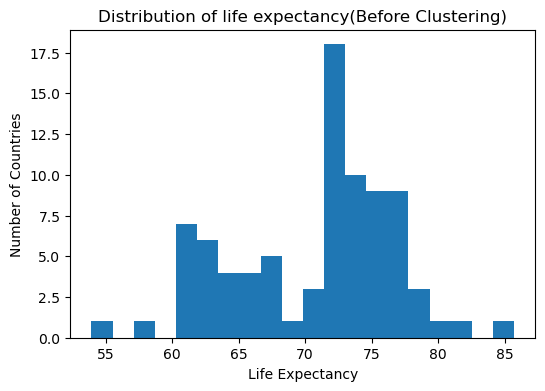

In [42]:
plt.figure(figsize=(6,4))
plt.hist(df["LifeExpectancy"],bins=20)
plt.xlabel("Life Expectancy")
plt.ylabel("Number of Countries")
plt.title("Distribution of life expectancy(Before Clustering)")
plt.show()

k	WCSS
1 	 336.00000000000006
2 	 206.4371719260381
3 	 142.06028324967593
4 	 122.46400641421171
5 	 68.7123470772603
6 	 56.09271840581915
7 	 51.082655173264186
8 	 41.70851027024396
9 	 31.213863029560212
10 	 27.04725098650772


C:\Users\Jhoshua Coutinho\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Jhoshua Coutinho\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Jhoshua Coutinho\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Jhoshua Coutinho\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMe

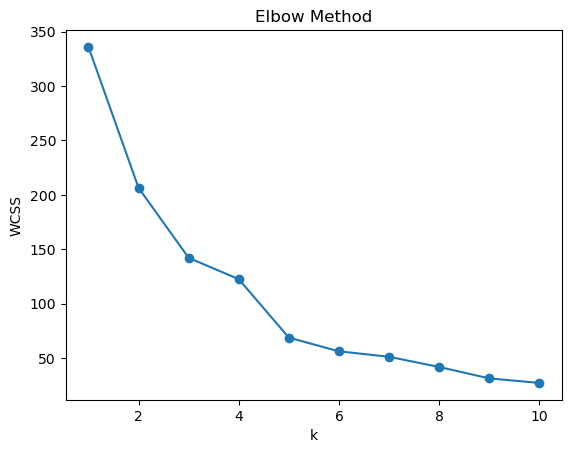

In [43]:
wcss=[]

for k in range(1,11):
    km = KMeans(n_clusters=k, random_state=0)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

print("k\tWCSS")
for i in range(10):
    print(i+1,"\t", wcss[i])
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("k")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()
    

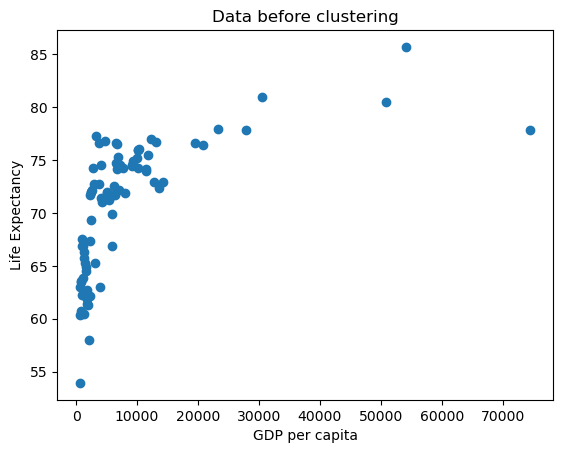

In [44]:
# Part 3 
plt.scatter(df["GDP"],df["LifeExpectancy"])

plt.xlabel("GDP per capita")
plt.ylabel("Life Expectancy")
plt.title("Data before clustering")
plt.show()

In [45]:
kmeans = KMeans(n_clusters=3, random_state=0)

#Label the clusters means give numbers to them and add it as column Kmeanscluster
labels_km = kmeans.fit_predict(X_scaled)
df["KMeansCluster"] = labels_km

C:\Users\Jhoshua Coutinho\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


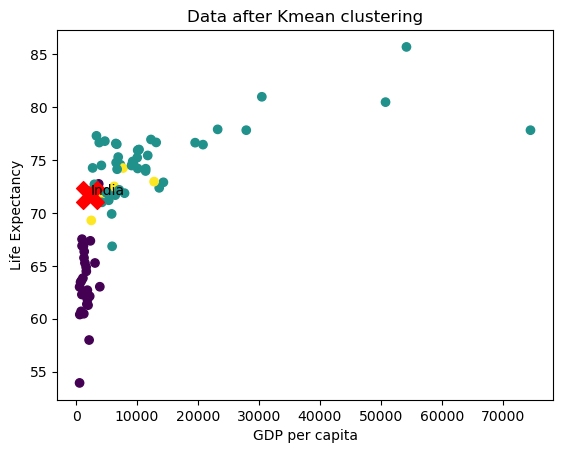

In [46]:
plt.scatter(df["GDP"],df["LifeExpectancy"], c=labels_km)

plt.xlabel("GDP per capita")
plt.ylabel("Life Expectancy")
plt.title("Data after Kmean clustering")
# highlight India
india = df.loc["India"]

plt.scatter(india["GDP"], india["LifeExpectancy"],
            s=400, color='Red', marker='X')
plt.text(india["GDP"], india["LifeExpectancy"],"India")
plt.show()

In [47]:
hc = AgglomerativeClustering(n_clusters=3)
labels_hc = hc.fit_predict(X_scaled)

df["Hierarchical Cluster"] = labels_hc

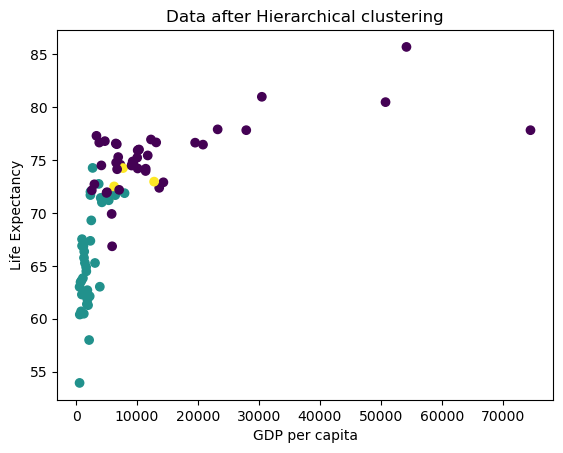

In [48]:
plt.scatter(df["GDP"],df["LifeExpectancy"], c=labels_hc)

plt.xlabel("GDP per capita")
plt.ylabel("Life Expectancy")
plt.title("Data after Hierarchical clustering")
plt.show()

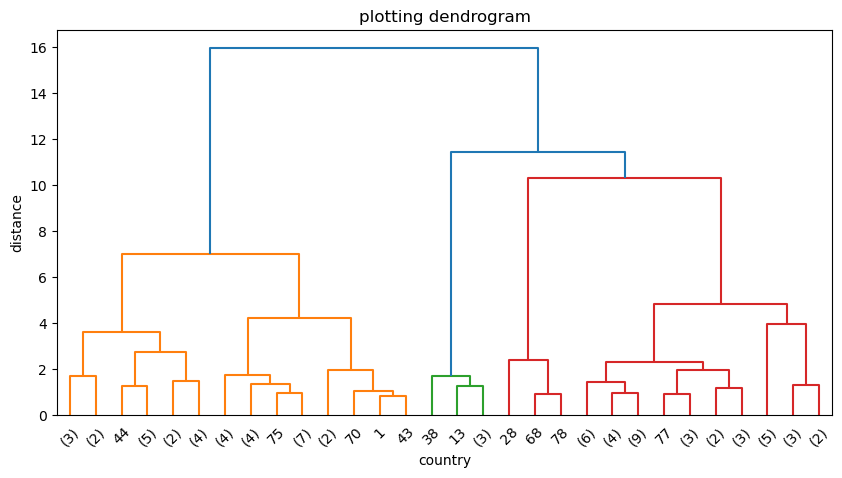

In [49]:
linked = linkage(X_scaled, method = "ward")
plt.figure(figsize=(10,5))
dendrogram(linked, truncate_mode='lastp', p=30)
plt.title("plotting dendrogram")
plt.xlabel("country")
plt.ylabel("distance")
plt.show()

In [50]:
country_name = "India"

result = df.loc[country_name]

print("Country:",country_name)
print("GDP per capita:", result["GDP"])
print("Population:", result["Population"])
print("Life Expectancy:",result["LifeExpectancy"])
print("Literacy Rate:",result["Literacy"])
print("KMeans Cluster:", result["KMeansCluster"])
print("Hierarchical Cluster", result["Hierarchical Cluster"])

Country: India
GDP per capita: 2347.44829434623
Population: 1425423212.0
Life Expectancy: 71.698
Literacy Rate: 76.3199996948242
KMeans Cluster: 1.0
Hierarchical Cluster 1.0


In [51]:
country_name = "North America"

result = df.loc[country_name]

print("Country:",country_name)
print("GDP per capita:", result["GDP"])
print("Population:", result["Population"])
print("Life Expectancy:",result["LifeExpectancy"])
print("Literacy Rate:",result["Literacy"])
print("KMeans Cluster:", result["KMeansCluster"])
print("Hierarchical Cluster", result["Hierarchical Cluster"])

Country: North America
GDP per capita: 74535.6365392629
Population: 373018004.0
Life Expectancy: 77.8327679594239
Literacy Rate: 98.7891464233398
KMeans Cluster: 1.0
Hierarchical Cluster 0.0


In [52]:
country_name = "Brazil"

result = df.loc[country_name]

print("Country:",country_name)
print("GDP per capita:", result["GDP"])
print("Population:", result["Population"])
print("Life Expectancy:",result["LifeExpectancy"])
print("Literacy Rate:",result["Literacy"])
print("KMeans Cluster:", result["KMeansCluster"])
print("Hierarchical Cluster", result["Hierarchical Cluster"])

Country: Brazil
GDP per capita: 9281.33282136864
Population: 210306415.0
Life Expectancy: 74.872
Literacy Rate: 94.3853874531348
KMeans Cluster: 1.0
Hierarchical Cluster 0.0


In [53]:
country_name = "Viet Nam"

result = df.loc[country_name]

print("Country:",country_name)
print("GDP per capita:", result["GDP"])
print("Population:", result["Population"])
print("Life Expectancy:",result["LifeExpectancy"])
print("Literacy Rate:",result["Literacy"])
print("KMeans Cluster:", result["KMeansCluster"])
print("Hierarchical Cluster", result["Hierarchical Cluster"])

Country: Viet Nam
GDP per capita: 4147.69777213621
Population: 99680655.0
Life Expectancy: 74.502
Literacy Rate: 96.129997253418
KMeans Cluster: 1.0
Hierarchical Cluster 0.0


In [54]:
country_name = "Bahrain"

result = df.loc[country_name]

print("Country:",country_name)
print("GDP per capita:", result["GDP"])
print("Population:", result["Population"])
print("Life Expectancy:",result["LifeExpectancy"])
print("Literacy Rate:",result["Literacy"])
print("KMeans Cluster:", result["KMeansCluster"])
print("Hierarchical Cluster", result["Hierarchical Cluster"])

Country: Bahrain
GDP per capita: 30470.5219276023
Population: 1524693.0
Life Expectancy: 80.992
Literacy Rate: 97.870002746582
KMeans Cluster: 1.0
Hierarchical Cluster 0.0


In [55]:
cluster_summary = df.groupby("KMeansCluster")[["GDP", "Population", "LifeExpectancy", "Literacy"]].mean()

print(cluster_summary)

                        GDP    Population  LifeExpectancy   Literacy
KMeansCluster                                                       
0               1601.971896  4.854521e+08       63.478867  66.779721
1              12288.225626  4.669122e+08       74.753258  92.910908
2               6437.349751  5.501554e+09       71.975830  84.851687
